### Lab 1.2: Binary Linear Classifier

In this lab you will try making a binary linear classifier using the [Palmer Penguins dataset](https://allisonhorst.github.io/palmerpenguins/).

You will need to install the packages ``sklearn``, ``palmerpenguins``, and ``mlxtend``.  In the following code block, the ``!`` indicates a shell command.

In [1]:
!pip install scikit-learn palmerpenguins mlxtend

In [2]:
import sklearn
from palmerpenguins import load_penguins
from mlxtend.plotting import plot_decision_regions

c:\Users\Logan\anaconda3\envs\csc487_env\Lib\site-packages\palmerpenguins\penguins.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


The dataset is loaded as a [Pandas dataframe](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html).  

In [3]:
df = load_penguins()
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


For simplicity we will drop any rows with missing values (encoded as NaNs).

In [4]:
df.dropna(inplace=True)
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007


Let's select just the Adelie and Chinstrap penguins.

In [5]:
df = df[(df['species']=='Adelie')|(df['species']=='Chinstrap')]

Now we will grab the flipper length and bill length to be the features (stored in ``X``) and the species as the labels (stored in ``y``).

In [6]:
X = df[['flipper_length_mm','bill_length_mm']].values
y = df['species'].map({'Adelie':0,'Chinstrap':1}).values

## Exercises

1. Fit a binary linear classifier using scikit-learn (see ``sklearn.linear_model.LogisticRegression``).

Plot the resulting classifier using ``plot_decision_regions(X, y, clf=model)``.


<Axes: >

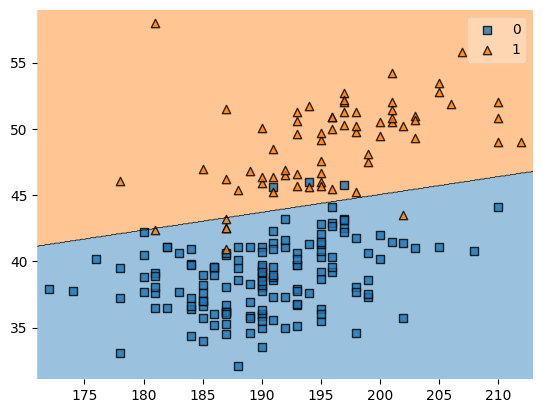

In [7]:
model = sklearn.linear_model.LogisticRegression().fit(X, y)

plot_decision_regions(X ,y, clf=model)

2. Print out the coefficients of the line (``model.coef_``).  Interpret these values (in terms of the direction of the line and also what they tell us about how the classifier operates).

In [8]:
model.coef_

array([[-0.15845623,  1.17936568]])

#### Interpretation
We can see that w1 = -0.158 and w2 = 1.179, approximately. The two features are x1 = flipper length and x2 = bill length. From the magnitudes of their weights, we can tell that bill length has a stronger correlation between classifying the two penguin species. w1<0 means that a greater flipper length is more associated with the "negative" species, aka the Adelie. w2>0 means that a greater bill length is more associated with the "positive" species, aka the Chinstrap.

3. Calculate and print out the accuracy of the classifier using the `.score` function.  Interpret this value.

In [9]:
model.score(X, y)

0.9579439252336449

#### Interpretation
The model's score of about 95.8% means that the model correctly identifies 95.8% of the penguin examples it was fit on.

4. Try different combinations of features and print out the accuracy for each one.  Interpret your results.

In [10]:
# Redefine X to include more features, leave y the same
X_new = df[['flipper_length_mm','bill_length_mm','bill_depth_mm','body_mass_g']].values

In [11]:
# Retrain the model
model_new = sklearn.linear_model.LogisticRegression().fit(X_new, y)

c:\Users\Logan\anaconda3\envs\csc487_env\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [12]:
# Examine model performance
print(f'Model coefficients: {model_new.coef_}')
print(f'Model score: {model_new.score(X_new, y)}')

Model coefficients: [[-0.13904798  1.75411693 -1.77839886 -0.00458836]]
Model score: 0.9906542056074766


#### Interpretation
Adding in the features of bill_depth_mm and body_mass_g improved the score from 95.8% up to 99%, which makes sense as adding more information from which the classifier can be trained on and use to classify the species should help improve its accuracy.

Additionally, examining the model's coefficients, it appears that bill_length and bill_depth have the strongest correlation with species since they have the greatest magnitudes. Thus, perhaps a smaller model with just those two features can achieve similar classification performance as the model with all four of the features.

In [13]:
X_2 = df[['bill_length_mm','bill_depth_mm']].values

In [14]:
# Retrain the model
model_2 = sklearn.linear_model.LogisticRegression().fit(X_2, y)

Model coefficients: [[ 1.35632252 -1.92221209]]
Model score: 0.9719626168224299


<Axes: >

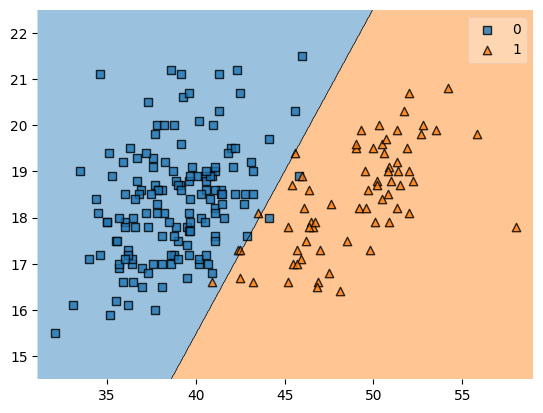

In [15]:
# Examine model performance
print(f'Model coefficients: {model_2.coef_}')
print(f'Model score: {model_2.score(X_2, y)}')
plot_decision_regions(X_2, y, clf=model_2)

#### Interpretation
It seems my hunch checks out, as the accuracy of 97% with just these two features is similar to that of all four features, and performs better than the model with just flipper_length and bill_length.

I also suspect that a model with the two features that had lower weight magnitudes would result in a lower score, as these features should have a weaker correlation in sorting the two species.

In [16]:
# Try a model with the weaker two features
X_3 = df[['flipper_length_mm','body_mass_g']].values

In [17]:
# Retrain the model
model_3 = sklearn.linear_model.LogisticRegression().fit(X_3, y)

Model coefficients: [[ 0.17106547 -0.00124681]]
Model score: 0.7383177570093458


<Axes: >

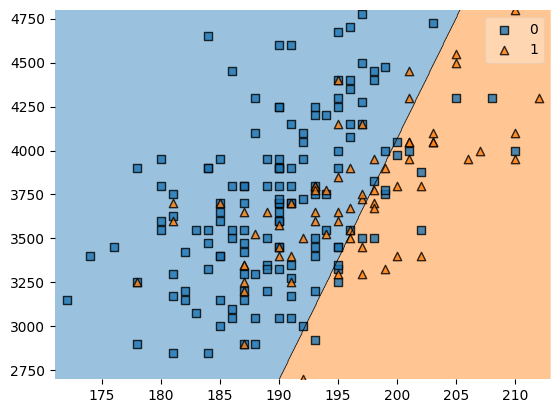

In [18]:
# Examine model performance
print(f'Model coefficients: {model_3.coef_}')
print(f'Model score: {model_3.score(X_3, y)}')
plot_decision_regions(X_3, y, clf=model_3)

#### Interpretation
From the significantly lower accuracy of 73.8% when using a model trained on only the two weaker features of flipper_length and body_mass, my thoughts seem to be confirmed. I.e. the best features to use for classifying the species were the bill_length and bill_depth.